In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [2]:
TRAIN_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/train"
VAL_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/val"
TEST_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/test"

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1234 images belonging to 3 classes.
Found 265 images belonging to 3 classes.
Found 265 images belonging to 3 classes.


In [6]:
# Get training labels
train_labels = train_generator.classes

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights_dict)

Class Weights:
{0: np.float64(0.7254556143445032), 1: np.float64(1.033500837520938), 2: np.float64(1.5291201982651796)}


In [7]:
print(train_generator.class_indices)

{'class_1': 0, 'class_2': 1, 'class_3': 2}


In [8]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [11]:
checkpoint = ModelCheckpoint(
    filepath=r"E:/ML Portfolio Projects/11. Retinopathy_Detection/models/mobilenetv2_best.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights_dict,
    callbacks=[
        checkpoint,
        early_stop,
        lr_reduce
    ]
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3979 - loss: 1.4142 - precision: 0.4043 - recall: 0.3225
Epoch 1: val_loss improved from None to 0.81531, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/mobilenetv2_best.keras

Epoch 1: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/mobilenetv2_best.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - accuracy: 0.4895 - loss: 1.1617 - precision: 0.5188 - recall: 0.4238 - val_accuracy: 0.6000 - val_loss: 0.8153 - val_precision: 0.7104 - val_recall: 0.4906 - learning_rate: 1.0000e-04
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.5809 - loss: 0.9024 - precision: 0.6304 - recall: 0.5186
Epoch 2: val_loss improved from 0.81531 to 0.70905, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/mobilenetv2_best.keras

Epoch 2: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/mobilenetv2_best.keras

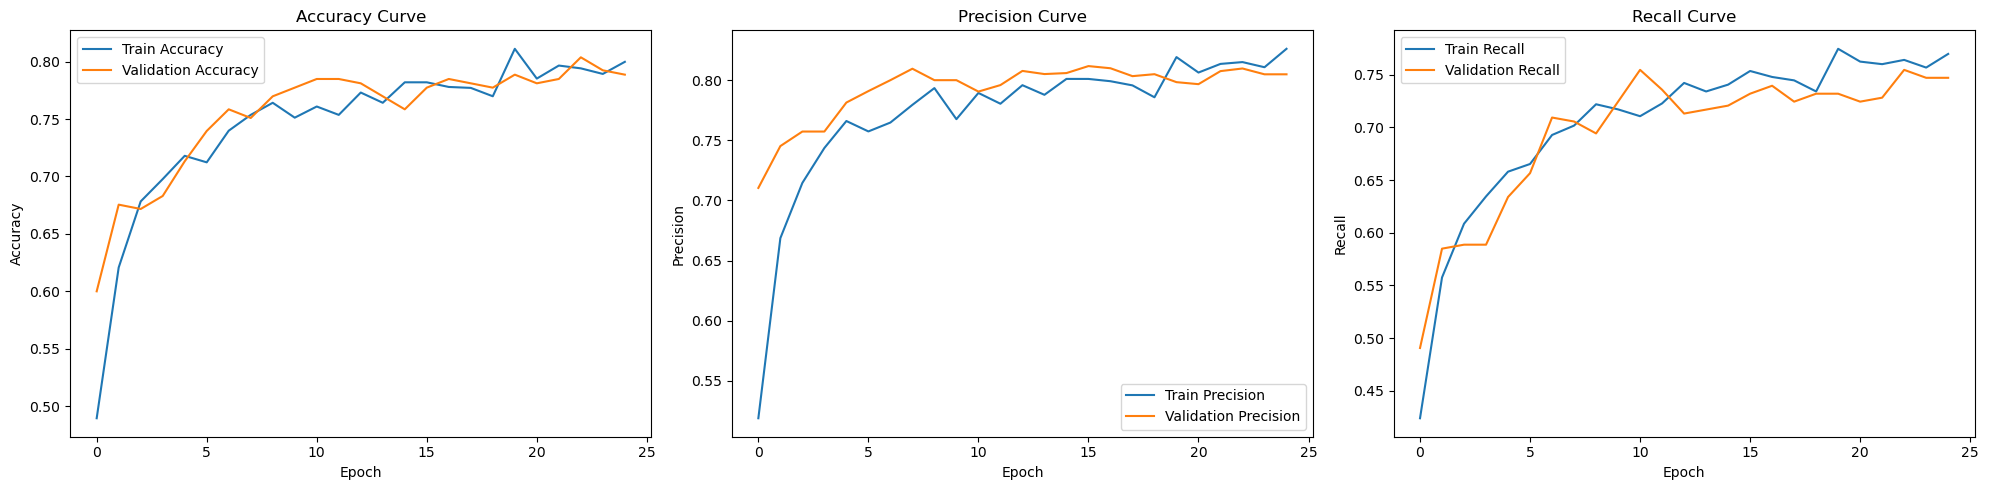

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ACCURACY
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')

axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()


# PRECISION
axes[1].plot(history.history['precision'], label='Train Precision')
axes[1].plot(history.history['val_precision'], label='Validation Precision')

axes[1].set_title("Precision Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Precision")
axes[1].legend()


# RECALL
axes[2].plot(history.history['recall'], label='Train Recall')
axes[2].plot(history.history['val_recall'], label='Validation Recall')

axes[2].set_title("Recall Curve")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Recall")
axes[2].legend()


plt.tight_layout()
plt.show()

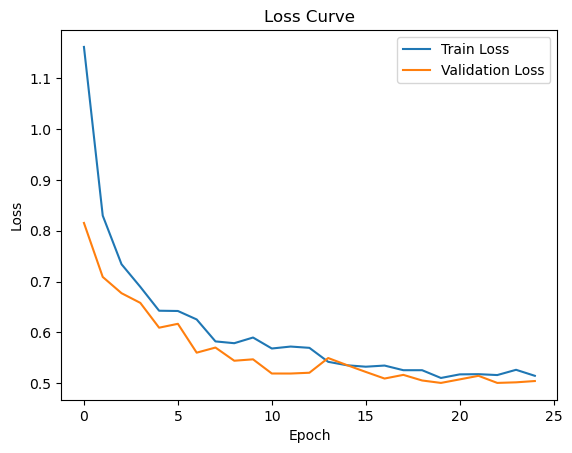

In [14]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [15]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.7887 - loss: 0.4710 - precision: 0.8255 - recall: 0.7321
Test Loss: 0.4710371196269989
Test Accuracy: 0.7886792421340942
Test Precision: 0.8255318999290466
Test Recall: 0.7320754528045654


In [16]:
# Predict probabilities
y_pred_probs = model.predict(test_generator)

# Convert probabilities to predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step


In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

     class_1       0.86      0.99      0.92       122
     class_2       0.81      0.50      0.62        86
     class_3       0.63      0.79      0.70        57

    accuracy                           0.79       265
   macro avg       0.77      0.76      0.75       265
weighted avg       0.79      0.79      0.78       265



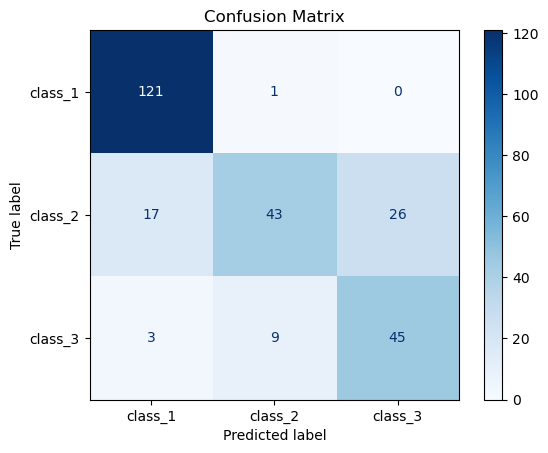

In [18]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

plt.show()

In [19]:
# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.9339056255119801
